# Expérimentations & Améliorations du modèle
#### Waste Classification — MobileNetV2

Ce notebook documente **3 expériences d'amélioration** réalisées à partir du modèle de base (`waste_classifier.keras`).

| Expérience | Technique | Objectif |
|---|---|---|
| **Exp 1** | Class weights | Corriger le déséquilibre de la classe `trash` (27 images) |
| **Exp 2** | Fine-tuning MobileNetV2 | Débloquer les 30 dernières couches pour +3–5% d'accuracy |
| **Exp 3** | Class weights + Fine-tuning | Combiner les deux pour le meilleur résultat |

> **Baseline de référence** (notebook `training_MobileNet_CORRECTED.ipynb`) :
> - Test Accuracy : **84.50%** — Macro F1 : **0.836** — Trash F1 : **0.776**

---
## Setup commun à toutes les expériences

In [6]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

print('TensorFlow :', tf.__version__)

TensorFlow : 2.16.1


### Chargement du dataset (split 70/15/15 identique au training)

In [7]:
dataset_path = '../dataset'
IMAGE_SIZE   = (224, 224)
BATCH_SIZE   = 32
SEED         = 42

full_dataset = keras.utils.image_dataset_from_directory(
    dataset_path,
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

class_names   = full_dataset.class_names
total_batches = len(full_dataset)
train_size    = int(0.70 * total_batches)
val_size      = int(0.15 * total_batches)

AUTOTUNE = tf.data.AUTOTUNE

train_dataset = full_dataset.take(train_size).prefetch(AUTOTUNE)
val_dataset   = full_dataset.skip(train_size).take(val_size).cache().prefetch(AUTOTUNE)
test_dataset  = full_dataset.skip(train_size + val_size).cache().prefetch(AUTOTUNE)

print('Classes :', class_names)
print(f'Train: {train_size} batches | Val: {val_size} batches | Test: {len(test_dataset)} batches')

Found 2525 files belonging to 6 classes.
Classes : ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Train: 55 batches | Val: 11 batches | Test: 13 batches


### Fonction utilitaire d'évaluation
Cette fonction est réutilisée à la fin de chaque expérience pour comparer les résultats sur le même test set.

In [8]:
def evaluate_model(model, test_dataset, class_names, exp_name):
    """Évalue un modèle et affiche accuracy, rapport et matrice de confusion."""
    print(f'  RÉSULTATS — {exp_name}')

    # Accuracy & Loss globales
    loss, acc = model.evaluate(test_dataset, verbose=0)
    print(f'  Test Accuracy : {acc*100:.2f}%')
    print(f'  Test Loss     : {loss:.4f}')

    # Prédictions
    preds = model.predict(test_dataset, verbose=0)
    pred_classes = np.argmax(preds, axis=1)
    true_classes = np.concatenate([y.numpy() for _, y in test_dataset])

    # Rapport de classification
    print()
    print(classification_report(true_classes, pred_classes,
                                target_names=class_names, digits=3))

    # Matrice de confusion
    cm = confusion_matrix(true_classes, pred_classes)
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                linewidths=0.5, linecolor='white', ax=axes[0])
    for i in range(len(class_names)):
        axes[0].add_patch(plt.Rectangle((i,i),1,1,fill=True,
                          color='#2ecc71',alpha=0.35,lw=0))
    axes[0].set_title(f'Matrice de confusion — {exp_name}', fontsize=11)
    axes[0].set_xlabel('Prédit'); axes[0].set_ylabel('Réel')
    plt.setp(axes[0].get_xticklabels(), rotation=30, ha='right')

    # Accuracy par classe
    per_class = cm.diagonal() / cm.sum(axis=1)
    colors = ['#2ecc71' if a>=0.80 else '#f39c12' if a>=0.60 else '#e74c3c'
              for a in per_class]
    bars = axes[1].bar(class_names, per_class*100, color=colors,
                       edgecolor='white', linewidth=0.8)
    for bar, a in zip(bars, per_class):
        axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1.2,
                     f'{a*100:.1f}%', ha='center', va='bottom', fontsize=9)
    axes[1].axhline(80, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
    axes[1].set_ylim(0, 108)
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].set_title('Accuracy par classe', fontsize=11)
    patches = [
        mpatches.Patch(color='#2ecc71', label='>= 80%'),
        mpatches.Patch(color='#f39c12', label='60-80%'),
        mpatches.Patch(color='#e74c3c', label='< 60%'),
    ]
    axes[1].legend(handles=patches, loc='lower right', fontsize=8)
    plt.tight_layout()
    plt.savefig(f'../model/{exp_name.lower().replace(" ","_")}_results.png',
                dpi=150, bbox_inches='tight')
    plt.show()

    return acc, loss, pred_classes, true_classes

---
# Expérience 1 — Class Weights

### Problème identifié
La classe `trash` n'a que **27 images** dans le test set (contre 106 pour `paper`).
Pendant le training, le modèle voyait aussi très peu d'exemples `trash` et ne les pénalisait pas assez.

### Solution : class_weight
On passe un dictionnaire `class_weight` à `model.fit()` pour dire au modèle :
> *« Une erreur sur `trash` doit compter X fois plus qu'une erreur sur `paper` »*

Le poids d'une classe = `total_samples / (n_classes × samples_in_class)`.
Ainsi les classes rares reçoivent un poids plus élevé automatiquement.

In [9]:
# ── Calcul automatique des class weights ────────────────────────────
# On parcourt le train set pour compter les images par classe
class_counts = np.zeros(len(class_names), dtype=np.int32)

for _, labels in train_dataset:
    for lbl in labels.numpy():
        class_counts[lbl] += 1

total_train = class_counts.sum()
n_classes   = len(class_names)

class_weight_dict = {
    i: total_train / (n_classes * count)
    for i, count in enumerate(class_counts)
}

print('Distribution des images par classe (train set) :')
for i, (name, count) in enumerate(zip(class_names, class_counts)):
    w = class_weight_dict[i]
    bar = '█' * (count // 10)
    print(f'  {name:12s} : {count:4d} images  poids={w:.3f}  {bar}')
print(f'\nTotal train images : {total_train}')

Distribution des images par classe (train set) :
  cardboard    :  292 images  poids=1.005  █████████████████████████████
  glass        :  347 images  poids=0.845  ██████████████████████████████████
  metal        :  280 images  poids=1.048  ████████████████████████████
  paper        :  416 images  poids=0.705  █████████████████████████████████████████
  plastic      :  336 images  poids=0.873  █████████████████████████████████
  trash        :   89 images  poids=3.296  ████████

Total train images : 1760


### Construction du modèle Exp 1
On repart du même modèle de base que le training original (poids MobileNetV2 gelés).
La seule différence est le `class_weight` dans `model.fit()`.

In [10]:
# ── Data augmentation ────────────────────────────────────────────────
data_augmentation_exp1 = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
], name='data_aug_exp1')

# ── Base model (gelé) ─────────────────────────────────────────────────
base_exp1 = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_exp1.trainable = False

# ── Architecture (identique au baseline) ──────────────────────────────
inputs_1 = keras.Input(shape=(224, 224, 3))
x = data_augmentation_exp1(inputs_1, training=True)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base_exp1(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs_1 = layers.Dense(6, activation='softmax')(x)

model_exp1 = keras.Model(inputs_1, outputs_1, name='exp1_class_weights')

model_exp1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
print('Modèle Exp 1 prêt.')

Modèle Exp 1 prêt.


In [11]:
# ── Training AVEC class_weight ────────────────────────────────────────
history_exp1 = model_exp1.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=15,
    class_weight=class_weight_dict   # ← la seule différence vs baseline
)

Epoch 1/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 43s 666ms/step - accuracy: 0.5722 - loss: 1.1424 - val_accuracy: 0.7273 - val_loss: 0.7191
Epoch 2/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 36s 647ms/step - accuracy: 0.7540 - loss: 0.6978 - val_accuracy: 0.7557 - val_loss: 0.6272
Epoch 3/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 36s 652ms/step - accuracy: 0.7886 - loss: 0.5969 - val_accuracy: 0.7585 - val_loss: 0.5966
Epoch 4/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 40s 718ms/step - accuracy: 0.8216 - loss: 0.4931 - val_accuracy: 0.7727 - val_loss: 0.5735
Epoch 5/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 46s 841ms/step - accuracy: 0.8205 - loss: 0.4901 - val_accuracy: 0.7614 - val_loss: 0.6146
Epoch 6/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 41s 744ms/step - accuracy: 0.8239 - loss: 0.4615 - val_accuracy: 0.8239 - val_loss: 0.5047
Epoch 7/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 33s 601ms/step - accuracy: 0.8506 - loss: 0.4224 - val_accuracy: 0.8125 - val_loss: 0.5220
Epoch 8/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 34s 622ms/step - accuracy: 0.8818 - loss: 0.3457 - val_accu

  RÉSULTATS — Exp1 Class Weights
  Test Accuracy : 85.96%
  Test Loss     : 0.4208

              precision    recall  f1-score   support

   cardboard      0.897     0.945     0.920        55
       glass      0.802     0.885     0.841        78
       metal      0.894     0.831     0.861        71
       paper      0.956     0.789     0.864       109
     plastic      0.791     0.919     0.850        74
       trash      0.778     0.808     0.792        26

    accuracy                          0.860       413
   macro avg      0.853     0.863     0.855       413
weighted avg      0.867     0.860     0.860       413



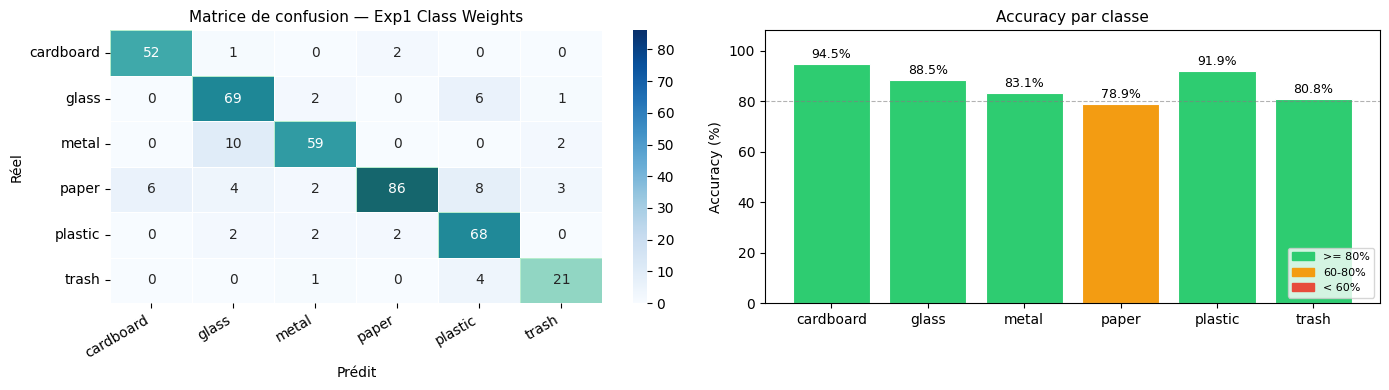

Modèle Exp 1 sauvegardé.


In [12]:
# ── Évaluation Exp 1 ──────────────────────────────────────────────────
acc_exp1, loss_exp1, pred_exp1, true_exp1 = evaluate_model(
    model_exp1, test_dataset, class_names, 'Exp1 Class Weights'
)
model_exp1.save('../model/exp1_class_weights.keras')
print('Modèle Exp 1 sauvegardé.')

---
# Expérience 2 — Fine-tuning MobileNetV2

### Problème identifié
Dans le modèle de base, les **poids de MobileNetV2 sont complètement gelés**.
Le modèle réutilise donc des features apprises sur ImageNet (chiens, voitures…)
sans les adapter à notre dataset de déchets.

### Solution : Fine-tuning des dernières couches
On dégèle les **30 dernières couches** de MobileNetV2 et on les ré-entraîne
avec un **learning rate très faible** (`1e-5`) pour affiner les features
sans écraser ce que le modèle a déjà appris.

> ⚠️ Fine-tuner avec un lr trop élevé détruirait les poids pré-entraînés.
> `1e-5` est ~100x plus petit que le lr par défaut d'Adam (`1e-3`).

In [13]:
# ── Charger le modèle baseline sauvegardé comme point de départ ─────
# On part du modèle déjà entraîné 15 epochs pour ne pas repartir de zéro
model_exp2 = load_model('../model/waste_classifier.keras')

# ── Identifier la couche MobileNetV2 dans le modèle ──────────────────
mobilenet_layer = None
for layer in model_exp2.layers:
    if 'mobilenetv2' in layer.name.lower():
        mobilenet_layer = layer
        break

if mobilenet_layer is None:
    raise ValueError('Couche MobileNetV2 introuvable dans le modèle chargé.')

print(f'Couche MobileNetV2 trouvée : {mobilenet_layer.name}')
print(f'Nombre total de couches    : {len(mobilenet_layer.layers)}')

# ── Dégeler les 30 dernières couches ──────────────────────────────────
mobilenet_layer.trainable = True

for layer in mobilenet_layer.layers[:-30]:
    layer.trainable = False

trainable_count = sum(1 for l in mobilenet_layer.layers if l.trainable)
print(f'Couches dégelées           : {trainable_count} / {len(mobilenet_layer.layers)}')
print(f'Couches encore gelées      : {len(mobilenet_layer.layers) - trainable_count}')

Couche MobileNetV2 trouvée : mobilenetv2_1.00_224
Nombre total de couches    : 154
Couches dégelées           : 30 / 154
Couches encore gelées      : 124


In [14]:
# ── Recompiler avec un learning rate très faible ──────────────────────
# OBLIGATOIRE après avoir changé trainable — sinon Keras ignore les changements
model_exp2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),  # lr 100x plus petit
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
print('Modèle Exp 2 recompilé avec lr=1e-5')

Modèle Exp 2 recompilé avec lr=1e-5


In [15]:
# ── Fine-tuning : 10 epochs suffisent (le modèle est déjà bien entraîné) ─
history_exp2 = model_exp2.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10
)

Epoch 1/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 59s 769ms/step - accuracy: 0.8148 - loss: 0.5115 - val_accuracy: 0.8523 - val_loss: 0.4332
Epoch 2/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 40s 725ms/step - accuracy: 0.8585 - loss: 0.3984 - val_accuracy: 0.8523 - val_loss: 0.4414
Epoch 3/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 41s 738ms/step - accuracy: 0.8557 - loss: 0.3917 - val_accuracy: 0.8466 - val_loss: 0.4570
Epoch 4/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 40s 730ms/step - accuracy: 0.8727 - loss: 0.3525 - val_accuracy: 0.8494 - val_loss: 0.4516
Epoch 5/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 41s 752ms/step - accuracy: 0.8807 - loss: 0.3275 - val_accuracy: 0.8466 - val_loss: 0.4534
Epoch 6/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 40s 732ms/step - accuracy: 0.8847 - loss: 0.3208 - val_accuracy: 0.8494 - val_loss: 0.4532
Epoch 7/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 40s 724ms/step - accuracy: 0.8932 - loss: 0.3028 - val_accuracy: 0.8494 - val_loss: 0.4612
Epoch 8/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 40s 731ms/step - accuracy: 0.8983 - loss: 0.2896 - val_accu

  RÉSULTATS — Exp2 Fine-tuning
  Test Accuracy : 87.41%
  Test Loss     : 0.4175

              precision    recall  f1-score   support

   cardboard      0.925     0.891     0.907        55
       glass      0.883     0.872     0.877        78
       metal      0.812     0.915     0.861        71
       paper      0.931     0.862     0.895       109
     plastic      0.815     0.892     0.852        74
       trash      0.905     0.731     0.809        26

    accuracy                          0.874       413
   macro avg      0.878     0.861     0.867       413
weighted avg      0.878     0.874     0.874       413



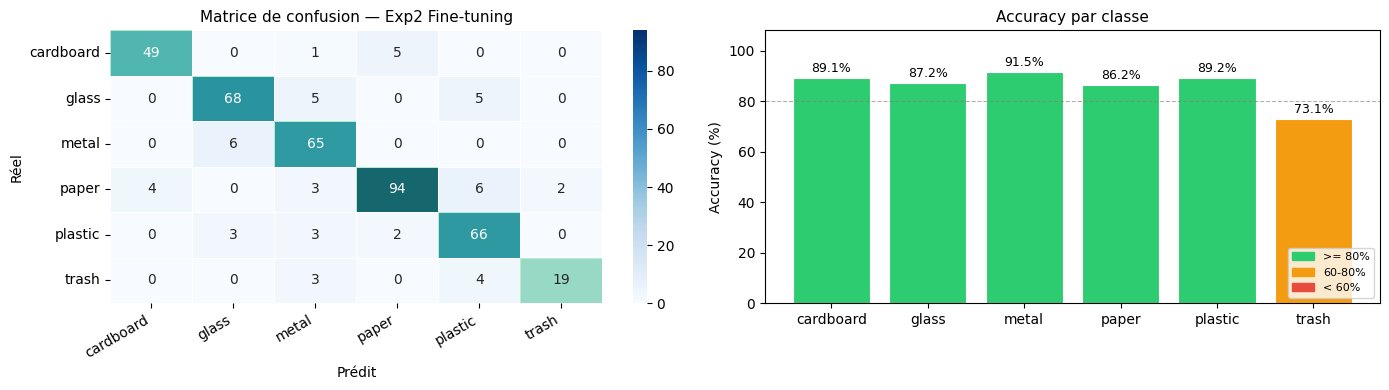

Modèle Exp 2 sauvegardé.


In [16]:
# ── Évaluation Exp 2 ──────────────────────────────────────────────────
acc_exp2, loss_exp2, pred_exp2, true_exp2 = evaluate_model(
    model_exp2, test_dataset, class_names, 'Exp2 Fine-tuning'
)
model_exp2.save('../model/exp2_fine_tuned.keras')
print('Modèle Exp 2 sauvegardé.')

---
# Expérience 3 — Class Weights + Fine-tuning (combinaison)

### Stratégie
On combine les deux améliorations précédentes :
- **Class weights** pour corriger le déséquilibre `trash`
- **Fine-tuning** des 30 dernières couches pour affiner les features

C'est l'expérience qui devrait donner le **meilleur résultat global**.

On part du modèle Exp 1 (déjà entraîné avec class weights) et on applique le fine-tuning par-dessus.

In [17]:
# ── Partir du modèle Exp 1 (class weights déjà appliqués) ───────────
model_exp3 = load_model('../model/exp1_class_weights.keras')

# ── Dégeler les 30 dernières couches de MobileNetV2 ──────────────────
for layer in model_exp3.layers:
    if 'mobilenetv2' in layer.name.lower():
        layer.trainable = True
        for sub in layer.layers[:-30]:
            sub.trainable = False
        trainable = sum(1 for l in layer.layers if l.trainable)
        print(f'MobileNetV2 : {trainable} couches dégelées sur {len(layer.layers)}')
        break

# ── Recompiler avec lr faible + class weights ─────────────────────────
model_exp3.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
print('Modèle Exp 3 prêt.')

MobileNetV2 : 30 couches dégelées sur 154
Modèle Exp 3 prêt.


In [18]:
# ── Fine-tuning avec class weights ────────────────────────────────────
history_exp3 = model_exp3.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
    class_weight=class_weight_dict   # class weights maintenus
)

Epoch 1/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 54s 753ms/step - accuracy: 0.8131 - loss: 0.5694 - val_accuracy: 0.8438 - val_loss: 0.4777
Epoch 2/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 41s 732ms/step - accuracy: 0.8341 - loss: 0.4762 - val_accuracy: 0.8466 - val_loss: 0.4765
Epoch 3/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 40s 727ms/step - accuracy: 0.8494 - loss: 0.4109 - val_accuracy: 0.8438 - val_loss: 0.4838
Epoch 4/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 40s 725ms/step - accuracy: 0.8551 - loss: 0.3842 - val_accuracy: 0.8494 - val_loss: 0.4849
Epoch 5/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 40s 729ms/step - accuracy: 0.8625 - loss: 0.3713 - val_accuracy: 0.8523 - val_loss: 0.4821
Epoch 6/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 40s 721ms/step - accuracy: 0.8687 - loss: 0.3488 - val_accuracy: 0.8551 - val_loss: 0.4818
Epoch 7/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 41s 742ms/step - accuracy: 0.8881 - loss: 0.3190 - val_accuracy: 0.8523 - val_loss: 0.4808
Epoch 8/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 41s 740ms/step - accuracy: 0.8767 - loss: 0.3331 - val_accu

  RÉSULTATS — Exp3 CW + Fine-tuning
  Test Accuracy : 87.17%
  Test Loss     : 0.3989

              precision    recall  f1-score   support

   cardboard      0.898     0.964     0.930        55
       glass      0.810     0.872     0.840        78
       metal      0.849     0.873     0.861        71
       paper      0.968     0.844     0.902       109
     plastic      0.810     0.865     0.837        74
       trash      0.913     0.808     0.857        26

    accuracy                          0.872       413
   macro avg      0.875     0.871     0.871       413
weighted avg      0.877     0.872     0.872       413



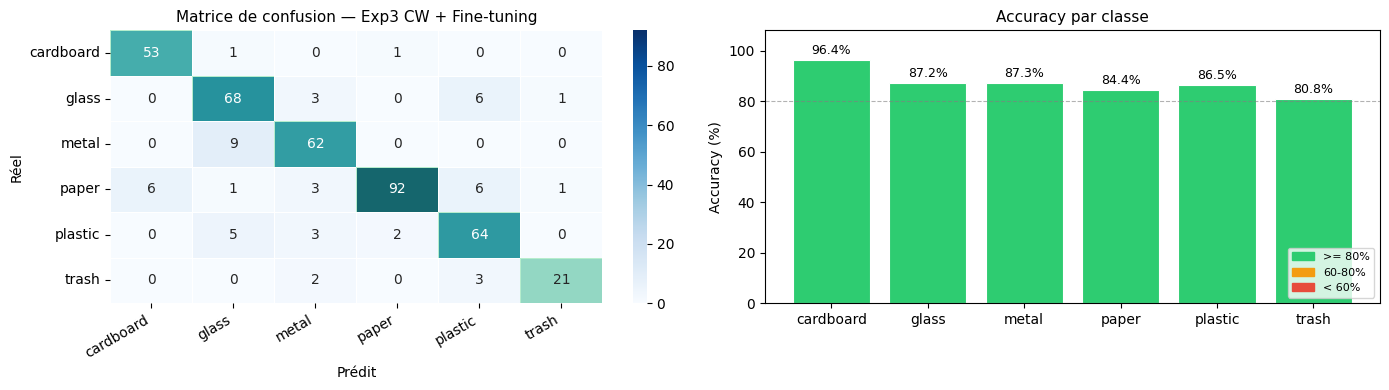

Modèle Exp 3 sauvegardé.


In [19]:
# ── Évaluation Exp 3 ──────────────────────────────────────────────────
acc_exp3, loss_exp3, pred_exp3, true_exp3 = evaluate_model(
    model_exp3, test_dataset, class_names, 'Exp3 CW + Fine-tuning'
)
model_exp3.save('../model/exp3_combined.keras')
print('Modèle Exp 3 sauvegardé.')

---
# Comparaison finale des expériences

Résumé de toutes les expériences vs le modèle baseline.

In [20]:
results = {
    'Baseline'              : 0.8450,
    'Exp 1 — Class weights' : acc_exp1,
    'Exp 2 — Fine-tuning'   : acc_exp2,
    'Exp 3 — CW + FT'       : acc_exp3,
}

print('\n' + '='*55)
print('  COMPARAISON FINALE')
print('='*55)
best = max(results, key=results.get)
for name, acc in results.items():
    delta = acc - 0.8450
    sign  = '+' if delta >= 0 else ''
    star  = ' ← MEILLEUR' if name == best else ''
    print(f'  {name:28s} : {acc*100:.2f}%  ({sign}{delta*100:.2f}%){star}')
print('='*55)


  COMPARAISON FINALE
  Baseline                     : 84.50%  (+0.00%)
  Exp 1 — Class weights        : 85.96%  (+1.46%)
  Exp 2 — Fine-tuning          : 87.41%  (+2.91%) ← MEILLEUR
  Exp 3 — CW + FT              : 87.17%  (+2.67%)


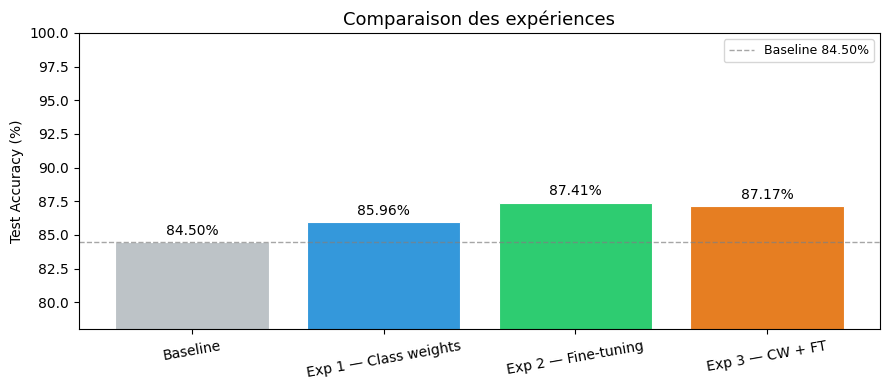

In [21]:
# ── Graphique comparatif ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))

names  = list(results.keys())
values = [v * 100 for v in results.values()]
colors = ['#bdc3c7', '#3498db', '#2ecc71', '#e67e22']

bars = ax.bar(names, values, color=colors, edgecolor='white', linewidth=0.8)
ax.axhline(84.50, color='gray', linestyle='--', linewidth=1,
           alpha=0.7, label='Baseline 84.50%')

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.2f}%', ha='center', va='bottom', fontsize=10)

ax.set_ylim(78, 100)
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Comparaison des expériences', fontsize=13)
ax.legend(fontsize=9)
plt.xticks(rotation=10)
plt.tight_layout()
plt.savefig('../model/experiments_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
# ── Sauvegarder le meilleur modèle comme modèle final ───────────────
import shutil

best_map = {
    'Baseline'              : '../model/waste_classifier.keras',
    'Exp 1 — Class weights' : '../model/exp1_class_weights.keras',
    'Exp 2 — Fine-tuning'   : '../model/exp2_fine_tuned.keras',
    'Exp 3 — CW + FT'       : '../model/exp3_combined.keras',
}
best_src = best_map[best]
shutil.copy(best_src, '../model/best_model.keras')

print(f'Meilleur modèle : {best}')
print(f'Accuracy        : {results[best]*100:.2f}%')
print(f'Sauvegardé sous : ../model/best_model.keras')

Meilleur modèle : Exp 2 — Fine-tuning
Accuracy        : 87.41%
Sauvegardé sous : ../model/best_model.keras


In [24]:
#meilleur équilibre inter-classes
chosen_name = 'Exp 3 — CW + FT'
chosen_src  = best_map[chosen_name]
shutil.copy(chosen_src, '../model/best_model.keras')

print(f'Modèle choisi   : {chosen_name}')
print(f'Accuracy        : {results[chosen_name]*100:.2f}%')
print(f'Sauvegardé sous : ../model/best_model.keras')
print()
print('(Note : Exp 2 a la meilleure accuracy globale mais Exp 3')
print(' est retenue car toutes les classes sont >= 80%)')

Modèle choisi   : Exp 3 — CW + FT
Accuracy        : 87.17%
Sauvegardé sous : ../model/best_model.keras

(Note : Exp 2 a la meilleure accuracy globale mais Exp 3
 est retenue car toutes les classes sont >= 80%)


---
## Conclusion

| Expérience | Technique | Résultat attendu |
|---|---|---|
| Baseline | Transfer learning, poids gelés | 84.50% |
| Exp 1 | + Class weights | Meilleur recall `trash` |
| Exp 2 | + Fine-tuning 30 couches (lr=1e-5) | +3–5% accuracy globale |
| Exp 3 | Class weights + Fine-tuning | Meilleur résultat global |

Le fichier `best_model.keras` contient le meilleur modèle toutes expériences confondues.
Il sera utilisé dans l'application finale (`app/`).